In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree

In [2]:
dataset = pd.read_csv(r'D:\HopeAI\Training\Week9-ML and Data Science Capstone\1. Data Collection\bmw_global_sales_2018_2025.csv')
dataset

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
...,...,...,...,...,...,...,...,...,...,...,...
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41


In [3]:
dataset.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [10]:
dataset=pd.get_dummies(dataset, drop_first=True)
dataset

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Region_Europe,Region_RestOfWorld,Region_USA,Model_5 Series,Model_MINI,Model_X3,Model_X5,Model_X7,Model_i4,Model_iX
0,2018,1,7822,47482,371404204,0.011,19.12,3.50,1.00,1,0,0,0,0,0,0,0,0,0
1,2018,1,10280,61685,634121800,0.019,19.12,3.50,1.00,1,0,0,1,0,0,0,0,0,0
2,2018,1,3105,58433,181434465,0.022,19.12,3.50,1.00,1,0,0,0,0,1,0,0,0,0
3,2018,1,7420,67955,504226100,0.021,19.12,3.50,1.00,1,0,0,0,0,0,1,0,0,0
4,2018,1,8474,92300,782150200,0.035,19.12,3.50,1.00,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067,2025,12,9281,68198,632945638,0.201,5.89,2.37,1.41,0,1,0,0,0,0,1,0,0,0
3068,2025,12,12785,91839,1174161615,0.203,5.89,2.37,1.41,0,1,0,0,0,0,0,1,0,0
3069,2025,12,4906,63437,311221922,0.180,5.89,2.37,1.41,0,1,0,0,0,0,0,0,1,0
3070,2025,12,7871,73867,581407157,0.196,5.89,2.37,1.41,0,1,0,0,0,0,0,0,0,1


In [11]:
#Get the numerical columns
X_Indep = dataset.drop("Units_Sold", axis=1)
Y_Dep = dataset["Units_Sold"]


In [12]:
#Split
X_Train, X_Test, y_train, y_test = train_test_split(X_Indep, Y_Dep, test_size=1/3, random_state=0)

In [19]:
#Random Forest
rfr = RandomForestRegressor(n_estimators=10, random_state=0)
rfr = rfr.fit(X_Train, y_train)


In [20]:
#check feature importance
pd.Series(rfr.feature_importances_, index=X_Train.columns).sort_values(ascending=False)

Revenue_EUR           0.828624
Avg_Price_EUR         0.164667
Model_X7              0.001402
Model_iX              0.001332
Model_MINI            0.000927
BEV_Share             0.000723
Premium_Share         0.000431
GDP_Growth            0.000431
Model_X3              0.000416
Month                 0.000333
Fuel_Price_Index      0.000316
Year                  0.000123
Region_Europe         0.000071
Region_USA            0.000058
Model_5 Series        0.000052
Region_RestOfWorld    0.000051
Model_X5              0.000031
Model_i4              0.000015
dtype: float64

In [21]:
y_pred = rfr.predict(X_Test)
y_pred

array([ 5616.9,  9652.6, 10822. , ...,  6539.3,  9673.7, 10298.6])

In [18]:
#Accuracy check
r2 = r2_score(y_test,y_pred)
print(r2)

0.9973269082649371


In [22]:
rfr.feature_importances_

array([1.22930627e-04, 3.32868963e-04, 1.64666541e-01, 8.28624280e-01,
       7.22678507e-04, 4.30801177e-04, 4.30501380e-04, 3.16076122e-04,
       7.07429035e-05, 5.07334049e-05, 5.81098047e-05, 5.15873540e-05,
       9.26994510e-04, 4.15532246e-04, 3.10983488e-05, 1.40216456e-03,
       1.45583262e-05, 1.33180055e-03])

In [23]:
rfr.max_features

'auto'

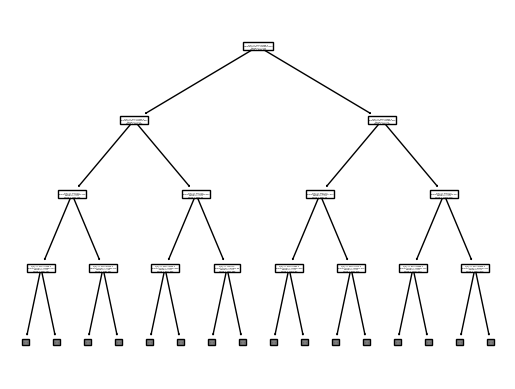

In [32]:
tree.plot_tree(rfr.estimators_[0], max_depth=3)
plt.show()